# YOLO V26 

https://www.ultralytics.com/        
https://docs.ultralytics.com/ko/models/yolo26/#key-features

In [1]:
# %pip install ultralytics

In [ ]:
from ultralytics import YOLO

# 모델 다운로드 
model = YOLO("yolo26n.pt")

# 모델 종류
# n(nano), l(large), x(extra?) 3가지 존재
#  작음 <------------> 큼,정확

In [ ]:
import cv2
from PIL import Image, ImageDraw, ImageFont
import gradio as gr


def detect_objects(image_array):
    #========== 모델 반환 데이터 탐색 =========
    
    # 1. 기본 세팅
    # response = model(image_array)

    # 2. 옵션 세팅
    response = model.predict(
        image_array,
        conf=0.2,
        iou=0.5
    )

    result = response[0]

    #========== 라벨 리스트 =========
    label_list = result.names
    print('라벨 리스트: ', label_list)

    #========== 바운딩박스 좌표, 신뢰도, 라벨 추출 =========
    bounding_box_list = result.boxes.xyxy.cpu().numpy()
    confidence_list = result.boxes.conf.cpu().numpy()
    label_index_list = result.boxes.cls.cpu().numpy()

    #========== 이미지 객체 ========= 
    # gradio에서는 이미지 색 변환 ㅔ외
    # image = Image.fromarray(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
    image = Image.fromarray(image_array.copy())
    draw = ImageDraw.Draw(image)

    #========== PIL로 이미지 그리기 ========= 
    for bounding_box, confidence, label_index in zip(bounding_box_list, confidence_list, label_index_list):
        # 바운딩 박스 그리기
        x1, y1, x2, y2 = bounding_box
        draw.rectangle( [(x1, y1), (x2, y2)], outline="red", width=2)
        draw.text(
            (x1 + 5, y1 + 5),
            text=f"{label_list[int(label_index)]}({confidence*100:.2f}%)", 
            fill="red", 
            font=ImageFont.load_default(size=17)
        )
        
        print("Bounding Box: ", bounding_box)
        print("Confidnece: ", confidence)
        print("Label Index: ", label_index)

    #========== 내장함수로 바운딩박스 그리기 =========
    # 실시간, 빠른 리턴 필요 시 사용
    # image = Image.fromarray(result.plot())

    return image

#========== 테스트 =========
# image_array = cv2.imread('sample2.jpg')
# detect_objects(image_array)


#========== Gradio =========
with gr.Blocks() as demo:
    #========== 이벤트 =========
    def stream_webcam(image_array):
        result_image = detect_objects(image_array)
        return result_image


    #========== 컴포넌트 =========
    with gr.Row():
        webcam_image = gr.Image(label="웹캠", sources="webcam",
                                webcam_options=gr.WebcamOptions(mirror=False))
        result_image = gr.Image(label="검출 화면", interactive=False, type="pil")

    #========== 이벤트 트리거 =========
    webcam_image.stream(stream_webcam, inputs=[webcam_image], outputs=[result_image],
                        stream_every=0.001) #덜 끊기는 이미지

demo.launch()

* Running on local URL:  http://127.0.0.1:7862
0: 384x640 (no detections), 1002.1ms
Speed: 2.8ms preprocess, 1002.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
라벨 리스트:  {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'ca

0: 384x640 (no detections), 349.5ms
Speed: 3.8ms preprocess, 349.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
라벨 리스트:  {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant'

boxes 정보)     
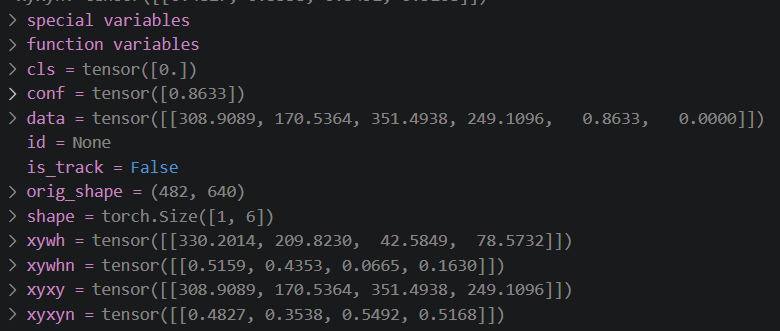
* cls : 클래스
* conf : 각 클래스에 대한 신뢰도

* xywh : 시작좌표 + 높이너비
* xyxy: 왼쪽위 좌표 + 오른쪽아래 좌표

=> tensor 객체: 데이터를 **cpu()로 들고온 다음 numpy로 변환**해줘야 함

출력되는 결과) 
Speed: 32.6ms preprocess, 125.2ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)
* preprocess : 이미지 크기 변환
* inference: 실제 추론에 걸린 시간